In [3]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from src.data_processing.splitting import split_data
from src.data_processing.esc50_dataset import ESC50Dataset
from src.models.CNN_model import AudioCNN

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Пътища
CSV_PATH = "../data/processed/esc50_segmented.csv"
AUDIO_DIR = "../data/processed/segmented_audio/"
MODEL_PATH = "../models/best_audiocnn_segmented.pth"

In [4]:
_, _, test_df = split_data(CSV_PATH)

# За да кодираме етикетите правилно, трябва да създадем енкодера върху целия сет
full_df = pd.read_csv(CSV_PATH)
dummy_dataset = ESC50Dataset(full_df, AUDIO_DIR)
encoder = dummy_dataset.label_encoder

test_dataset = ESC50Dataset(test_df, AUDIO_DIR, label_encoder=encoder)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
model = AudioCNN(n_classes=50).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

AudioCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchnorm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchnorm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchnorm3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=50, bias=True)
)

In [6]:
all_preds = []
all_labels = []

print("Оценяване на модела върху Тестовия набор...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Оценяване на модела върху Тестовия набор...


In [7]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"🔥 Финална точност на Тестовия сет (Test Accuracy): {test_accuracy * 100:.2f}%\n")

🔥 Финална точност на Тестовия сет (Test Accuracy): 49.50%



In [17]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"🔥 Финална точност на Тестовия сет (Test Accuracy): {test_accuracy * 100:.2f}%\n")

# --- НОВ КОД ЗА PRECISION И RECALL ---
# Взимаме имената на всички 50 класа
all_class_names = encoder.inverse_transform(np.arange(50))

# Генерираме детайлен доклад
report = classification_report(all_labels, all_preds, target_names=all_class_names)

print("📊 ДЕТАЙЛЕН ДОКЛАД (PRECISION, RECALL, F1-SCORE):")
print(report)

🔥 Финална точност на Тестовия сет (Test Accuracy): 49.50%

📊 ДЕТАЙЛЕН ДОКЛАД (PRECISION, RECALL, F1-SCORE):
                  precision    recall  f1-score   support

        airplane       0.33      0.20      0.25        30
       breathing       0.11      0.04      0.06        25
  brushing_teeth       0.70      0.68      0.69        28
     can_opening       0.00      0.00      0.00        11
        car_horn       0.28      0.42      0.33        19
             cat       0.25      0.11      0.15        19
        chainsaw       0.90      0.64      0.75        28
  chirping_birds       0.74      0.89      0.81        28
    church_bells       0.93      0.87      0.90        30
        clapping       0.29      0.19      0.23        26
     clock_alarm       0.48      0.59      0.53        27
      clock_tick       0.50      0.80      0.62        25
        coughing       0.67      0.13      0.22        15
             cow       0.36      0.26      0.30        19
  crackling_fire     

In [18]:
classes_to_show = 50
cm = confusion_matrix(all_labels, all_preds)
cm_subset = cm[:classes_to_show, :classes_to_show]
class_names = encoder.inverse_transform(np.arange(50))[:classes_to_show]

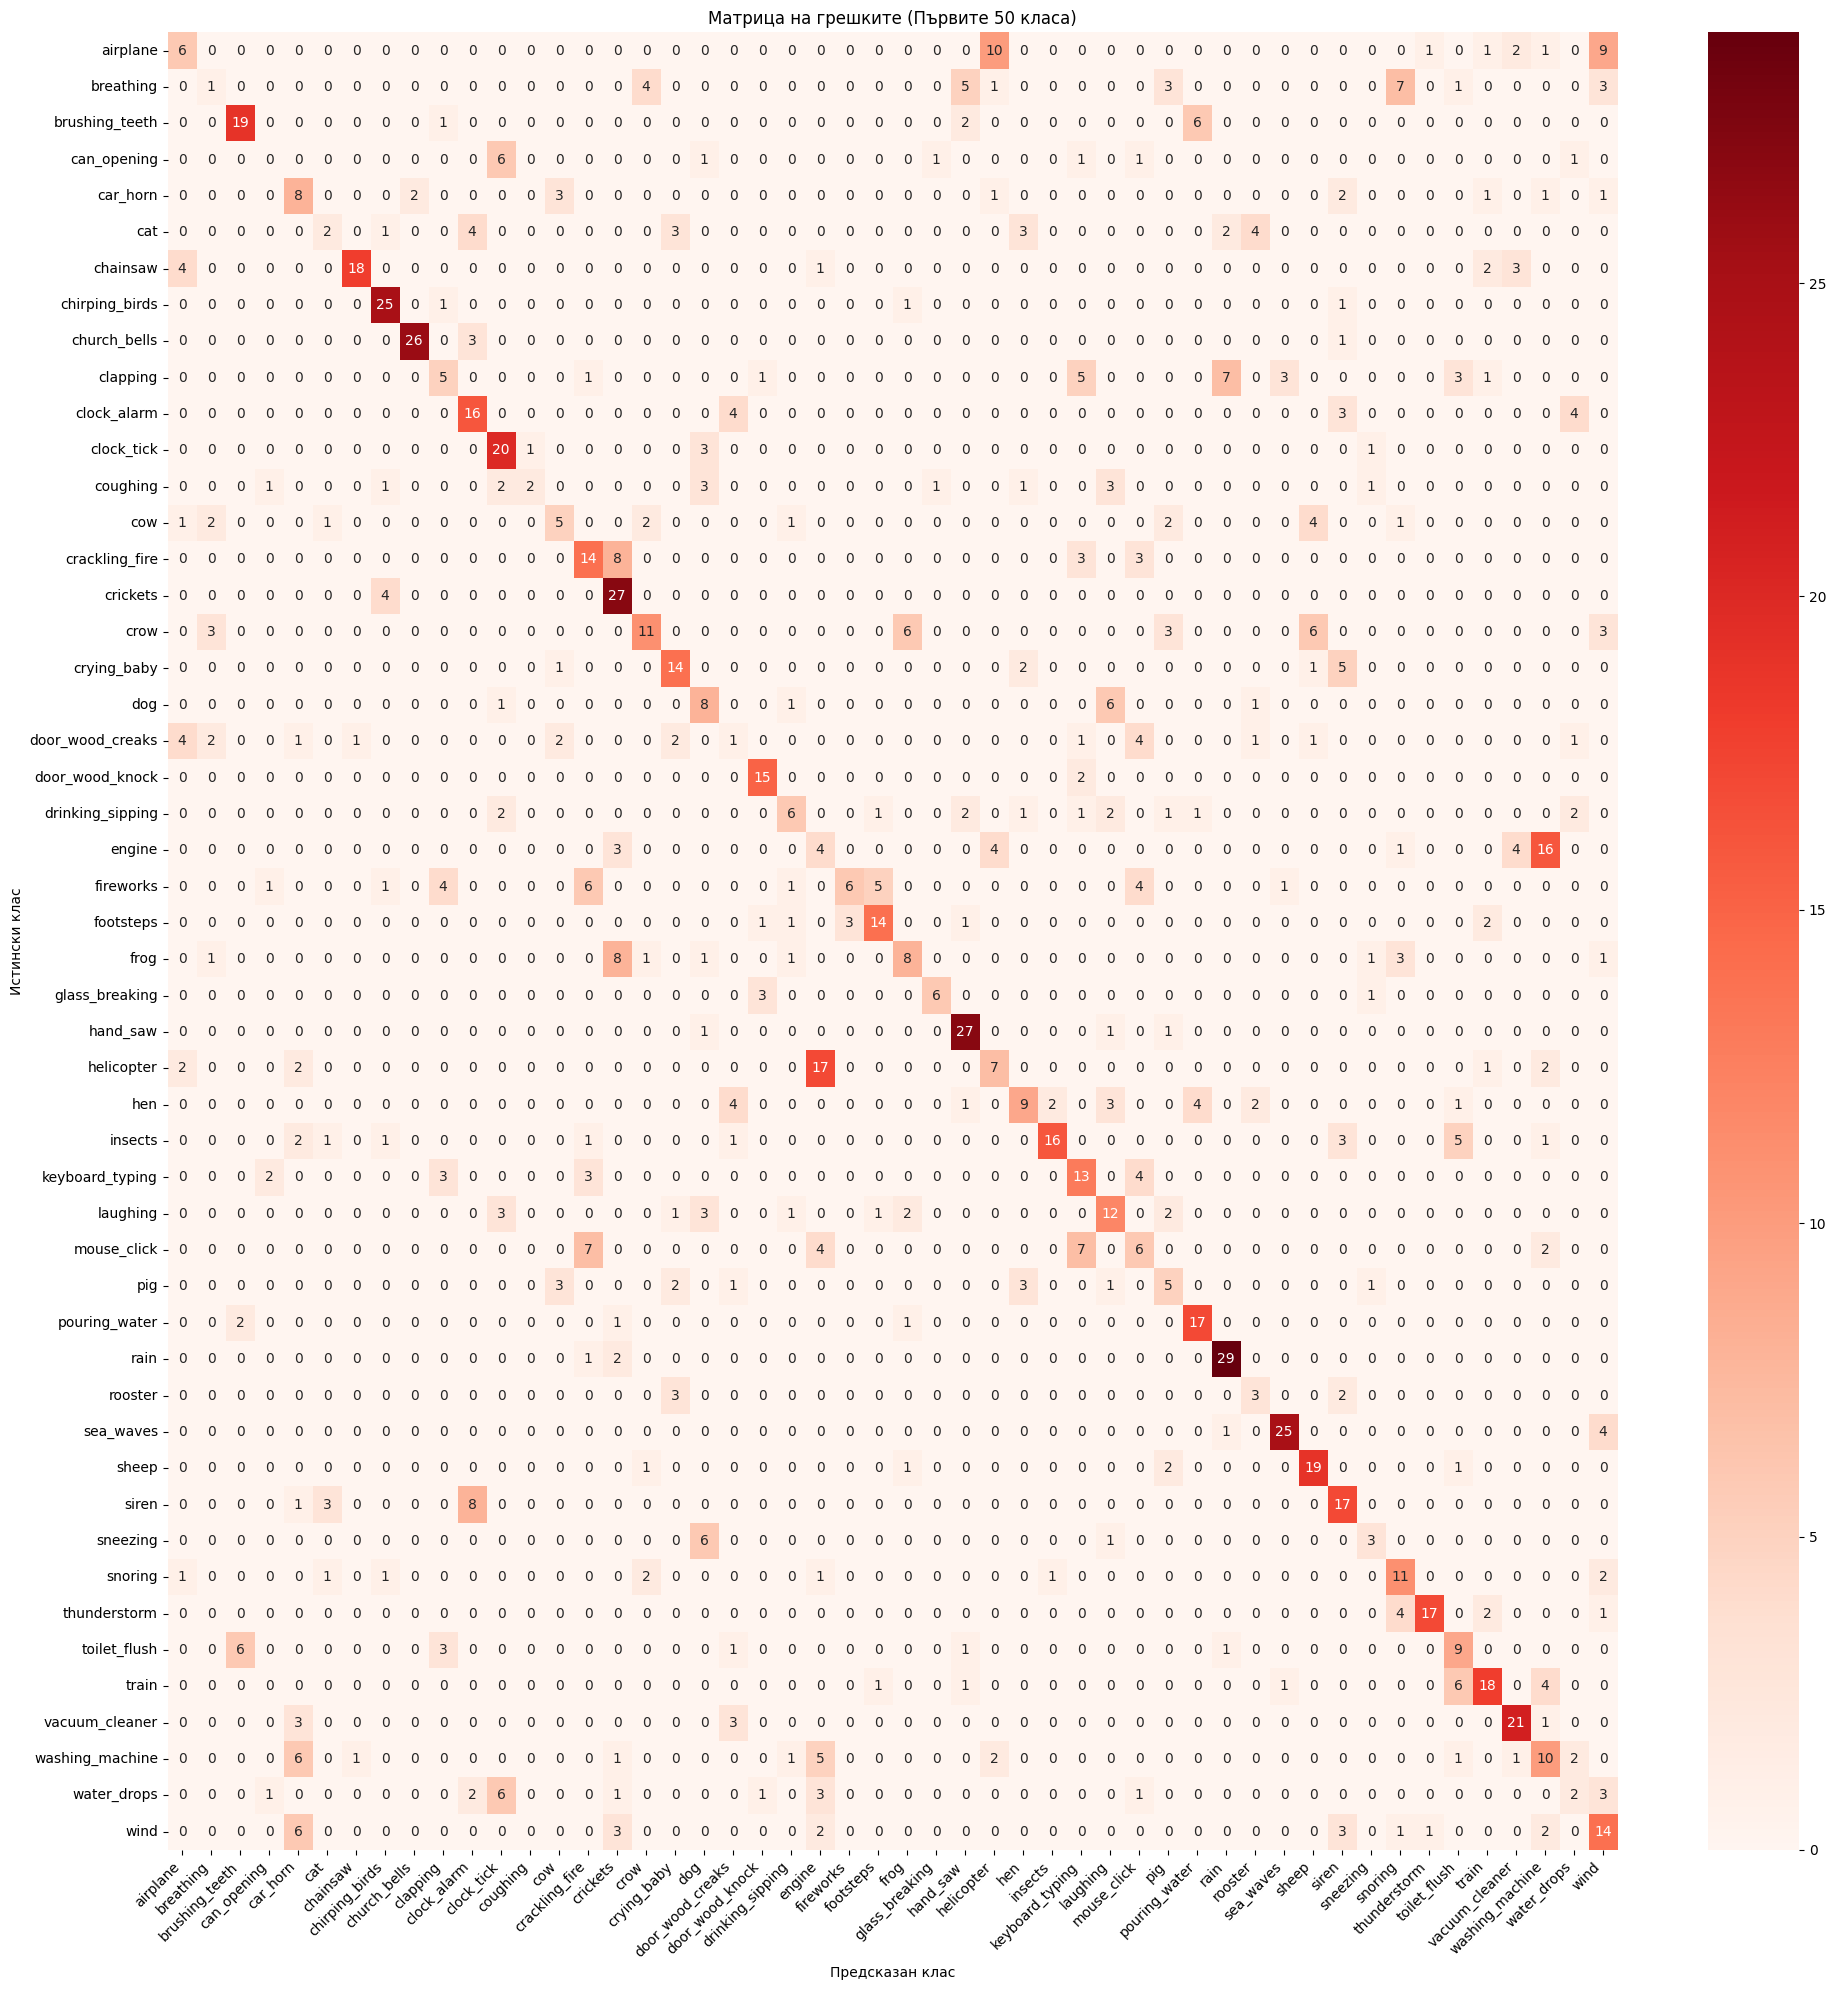

In [19]:
plt.figure(figsize=(20, 20))
sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Матрица на грешките (Първите {classes_to_show} класа)')
plt.ylabel('Истински клас')
plt.xlabel('Предсказан клас')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

📊 Анализ на резултатите и оценка на модела

Финалната оценка на базовата конволюционна архитектура (AudioCNN) върху напълно непознатия Тестов набор (Fold 5) постигна обща точност от 49.50%. За да се оцени обективно този резултат, трябва да се вземе предвид, че наборът от данни ESC-50 съдържа 50 балансирани класа. При сляпо налучкване (random guessing) очакваната точност е едва 2.0%. Постигнатият резултат доказва категорично, че моделът е успял да извлече генерализируеми времево-честотни характеристики от Мел-спектрограмите, превръщайки акустичния проблем в успешен проблем на компютърното зрение.

Детайлният анализ на Доклада за класификация (Classification Report) и Матрицата на грешките (Confusion Matrix) разкрива важни зависимости между архитектурата на модела и физическата природа на звуците:

1. Класове с висока разделителна способност (High F1-Score)

Моделът показва изключителна увереност при звуци със стационарна или силно изразена хармонична структура. Най-високи резултати (F1-score) се наблюдават при:

church_bells (Църковни камбани - 0.90): Те генерират ясни, продължителни хоризонтални спектрални линии (основен тон и обертонове), които не се променят рязко във времето.

chirping_birds (Пеещи птици - 0.81): Характеризират се с резки, високочестотни модулации в много специфичен и тесен честотен диапазон (над 2000 Hz), където почти няма фонов шум.

chainsaw (Резачка - 0.75): Излъчва плътна, нискочестотна енергия с ясно изразен механичен ритъм (амплитудна модулация).

Извод за модела: Плитката CNN архитектура с 3 конволюционни слоя (която изградихме) се справя отлично с разпознаването на глобални, повтарящи се текстури, които заемат голяма част от 2-секундния прозорец.

2. Интелигентни акустични грешки (Logical Acoustic Confusions)

Анализът на матрицата на грешките показва, че моделът не разпределя грешките си на случаен принцип, а формира "клъстери на объркване" между акустично подобни класове. Това е индикатор, че мрежата е научила смислени репрезентации на звука:

Широколентов бял шум (Broadband Noise): Класът airplane (самолет) често се класифицира погрешно като wind (вятър). И двата звука представляват широколентов шум без ясни спектрални върхове (пикове). Тяхната енергия е разпределена равномерно, което ги прави визуално идентични в Мел-спектрограмата при толкова кратък времеви прозорец.

Двигатели с вътрешно горене: engine (автомобилен двигател) се бърка с train (влак) и helicopter (хеликоптер). Общото между тях е силната концентрация на енергия в най-ниските честотни ленти (под 500 Hz) и липсата на високочестотни детайли.

Биологични ритмични звуци: Класът breathing (дишане) се бърка системно със snoring (хъркане). Те споделят еднаква времева периодичност (вдишване/издишване), като разликата е само в лекото наличие на вибрация при хъркането, което плитката мрежа трудно улавя.

Високочестотни транзиенти: Пукането на crackling_fire (огън) се бърка с crickets (щурци). И двата класа се изобразяват като серия от много кратки, вертикални високочестотни импулси.

3. Архитектурни ограничения при слабите класове (Underperforming Classes)

Звуци като can_opening (отваряне на кенче) и door_wood_creaks (скърцане на врата) имат показатели, близки до нулата. Причината за това е времевият им характер. Те са импулсивни звуци (transients), които продължават по-малко от 0.5 секунди.

В един 2-секунден прозорец, тези събития заемат много малък процент от пикселите на спектрограмата.

Операциите MaxPool2d и най-вече AdaptiveAvgPool2d (Global Average Pooling) в нашата архитектура усредняват стойностите по цялата площ на тензора. При много кратки звуци, усредняването буквално "изтрива" техния сигнал, като го поглъща в общата тишина наоколо.

4. Заключение и бъдещи насоки (Capacity Bottleneck & Transfer Learning)

Достигнатата точност от ~50% бележи "тавана на капацитета" (Capacity Bottleneck) на създадената базова CNN архитектура. Мрежа с едва 3 конволюционни слоя няма достатъчна дълбочина (брой параметри и сложни нелинейни трансформации), за да извлече сложни йерархични признаци, които биха различили фините детайли между вятър и самолет или дъжд и морски вълни.

За преодоляване на това ограничение и достигане на индустриални стандарти (точност >80%), системата има нужда от архитектурно надграждане. Логичната следваща стъпка е използването на Трансферно обучение (Transfer Learning) – интегриране на дълбоки архитектури (като ResNet-18 или MobileNet), предварително обучени върху огромни масиви от изображения (ImageNet) или звуци (AudioSet), които разполагат с много по-мощни и усъвършенствани филтри за извличане на текстурни характеристики.